# CIFAR-10 Image Classification using CNN
### Midterm Project — Deep Learning Pipeline

**Dataset:** CIFAR-10 (60,000 images · 32×32 · RGB · 10 classes)  
**Framework:** TensorFlow / Keras  
**Model:** Custom CNN built from scratch

---
**Pipeline Steps:**
1. Import Libraries  
2. Load Dataset  
3. Preprocess Data  
4. Build CNN Model  
5. Compile Model  
6. Train Model  
7. Evaluate Model  
8. Classification Report  
9. Save Model  
10. Load Model  
11. Realtime Prediction  
12. Plot Training Results

## Section 1 — Import Libraries

In [13]:
# ============================================================
# SECTION 1: IMPORT LIBRARIES
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import argparse

# TensorFlow / Keras modules
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Sklearn metrics
from sklearn.metrics import classification_report

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print("All libraries imported successfully ✅")

TensorFlow version : 2.20.0
NumPy version      : 2.0.2
All libraries imported successfully ✅


In [14]:
# ---- Kiểm tra nội dung MyDrive (chạy nếu chưa biết tên thư mục) ----
import os
myDrive = '/content/drive/MyDrive'
print("Danh sách thư mục trong MyDrive:")
for item in sorted(os.listdir(myDrive)):
    full = os.path.join(myDrive, item)
    kind = "📁" if os.path.isdir(full) else "📄"
    print(f"  {kind}  {item}")

Danh sách thư mục trong MyDrive:


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive'

## Section 2 — Load Dataset

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
CIFAR-10 dataset loaded successfully ✅

Raw shapes:
  x_train : (50000, 32, 32, 3)
  y_train : (50000, 1)
  x_test  : (10000, 32, 32, 3)
  y_test  : (10000, 1)
CIFAR-10 dataset loaded successfully ✅

Raw shapes:
  x_train : (50000, 32, 32, 3)
  y_train : (50000, 1)
  x_test  : (10000, 32, 32, 3)
  y_test  : (10000, 1)


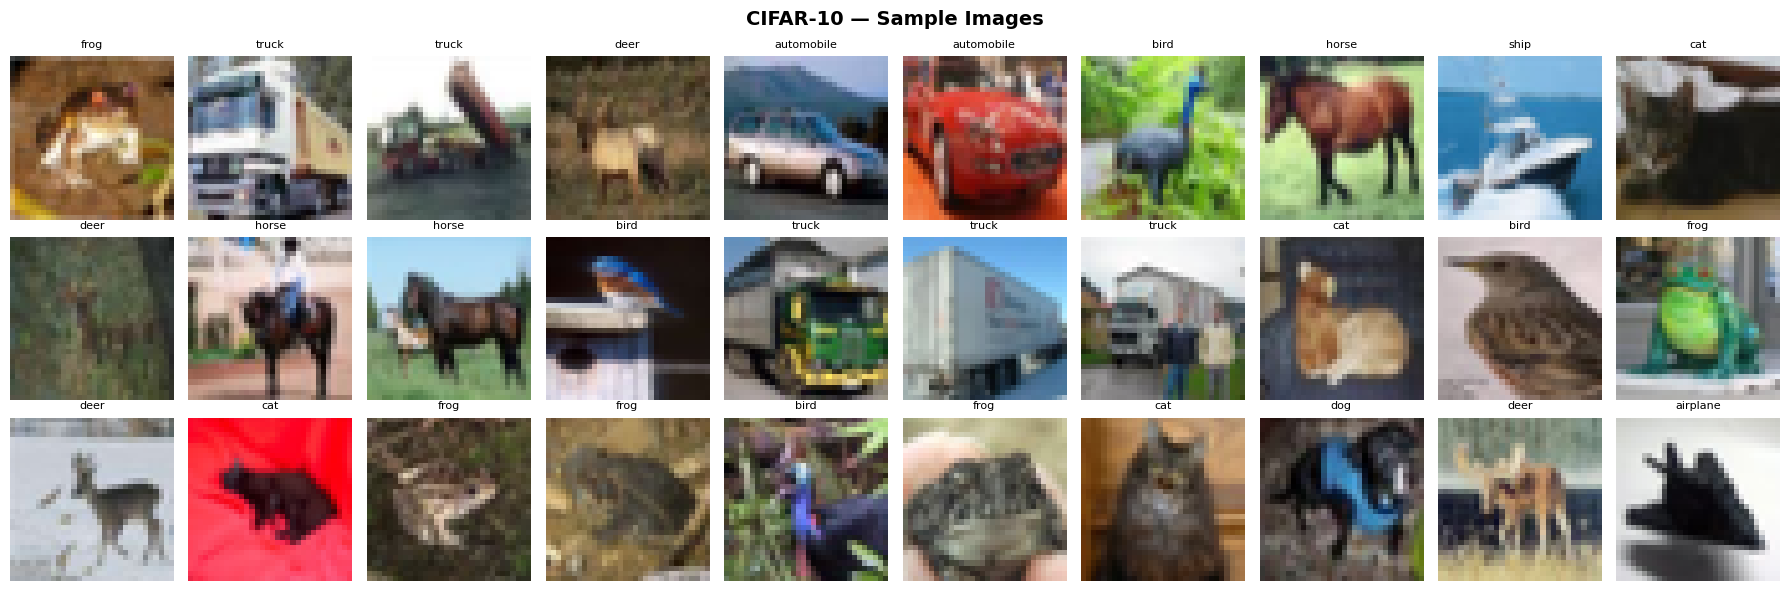

In [ ]:
# ============================================================
# SECTION 2: LOAD DATASET FROM GOOGLE DRIVE (Shared Folder)
# ============================================================
# Link shared folder:
#   https://drive.google.com/drive/folders/1di_gPUA0gmyMzMXhiaY0mXFrEA6rue_d
#
# Cách dùng:
#   Bước 1 — Vào link trên, click "Add shortcut to Drive"
#             (Thêm lối tắt vào Drive của bạn)
#   Bước 2 — Chọn vị trí: My Drive  →  "Add shortcut"
#   Bước 3 — Chạy cell này, Drive sẽ được mount tự động
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ---- Bước 1: Mount Google Drive ----
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
print("Google Drive mounted ✅")

# ---- Bước 2: Đường dẫn đến dataset ----
# Sau khi "Add shortcut to Drive", thư mục sẽ xuất hiện tại:
#   /content/drive/MyDrive/<tên thư mục trong shared folder>
#
# Kiểm tra tên thư mục thực tế bằng lệnh:
#   !ls "/content/drive/MyDrive/"

FOLDER_NAME  = 'cifar10'                                       # ← đổi nếu tên khác
DATASET_PATH = f'/content/drive/MyDrive/{FOLDER_NAME}'
TRAIN_DIR    = os.path.join(DATASET_PATH, 'train')
TEST_DIR     = os.path.join(DATASET_PATH, 'test')

# Kiểm tra thư mục tồn tại
if not os.path.isdir(DATASET_PATH):
    raise FileNotFoundError(
        f"\n❌ Không tìm thấy: {DATASET_PATH}\n"
        "   → Hãy chắc chắn bạn đã 'Add shortcut to Drive' cho folder shared ở trên.\n"
        "   → Chạy ô bên dưới để xem danh sách thư mục trong MyDrive."
    )
print(f"Dataset path found: {DATASET_PATH} ✅")

# ---- Bước 3: Định nghĩa nhãn ----
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]
label_map = {name: idx for idx, name in enumerate(class_names)}

# ---- Bước 4: Hàm đọc ảnh từ thư mục ----
def load_images_from_folder(root_dir, class_names, label_map, img_size=(32, 32)):
    """
    Đọc toàn bộ ảnh từ cấu trúc thư mục root_dir/<class_name>/*.png
    Trả về:  images  → np.array shape (N, 32, 32, 3), dtype uint8
             labels  → np.array shape (N, 1),          dtype int
    """
    images, labels = [], []
    for class_name in class_names:
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir):
            print(f"  ⚠️  Không tìm thấy thư mục: {class_dir}")
            continue
        file_list = sorted([f for f in os.listdir(class_dir)
                            if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        for fname in file_list:
            fpath = os.path.join(class_dir, fname)
            try:
                img = Image.open(fpath).convert('RGB').resize(img_size)
                images.append(np.array(img))
                labels.append(label_map[class_name])
            except Exception as e:
                print(f"  ⚠️  Bỏ qua {fname}: {e}")
        print(f"  Loaded {len(file_list):>5} images  ←  {class_name}")
    return np.array(images, dtype=np.uint8), np.array(labels, dtype=np.int64).reshape(-1, 1)

# ---- Bước 5: Đọc dữ liệu ----
print("\nĐang đọc dữ liệu train …")
x_train, y_train = load_images_from_folder(TRAIN_DIR, class_names, label_map)
print("\nĐang đọc dữ liệu test …")
x_test,  y_test  = load_images_from_folder(TEST_DIR,  class_names, label_map)

print("\nCIFAR-10 dataset loaded from Google Drive ✅")
print(f"  x_train : {x_train.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  x_test  : {x_test.shape}")
print(f"  y_test  : {y_test.shape}")

# ---- Bước 6: Xem trước một số ảnh ----
fig, axes = plt.subplots(3, 10, figsize=(18, 6))
fig.suptitle("CIFAR-10 — Sample Images (from Google Drive)", fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i][0]], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Section 3 — Preprocess Data

In [ ]:
# ============================================================
# SECTION 3: PREPROCESS DATA
# ============================================================

# --- Step 1: Normalize pixel values to [0, 1] ---
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# --- Step 2: Convert integer labels to one-hot encoding ---
# e.g., class 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train_ohe = to_categorical(y_train, num_classes=10)
y_test_ohe  = to_categorical(y_test,  num_classes=10)

# --- Step 3: Print dataset shapes ---
print("After preprocessing:")
print(f"  x_train shape : {x_train.shape}   (50,000 training images, 32×32, RGB)")
print(f"  y_train shape : {y_train_ohe.shape}  (one-hot labels)")
print(f"  x_test  shape : {x_test.shape}   (10,000 test images,     32×32, RGB)")
print(f"  y_test  shape : {y_test_ohe.shape}  (one-hot labels)")
print(f"\nPixel value range : [{x_train.min():.1f}, {x_train.max():.1f}]")
print("Preprocessing complete ✅")

After preprocessing:
  x_train shape : (50000, 32, 32, 3)   (50,000 training images, 32×32, RGB)
  y_train shape : (50000, 10)  (one-hot labels)
  x_test  shape : (10000, 32, 32, 3)   (10,000 test images,     32×32, RGB)
  y_test  shape : (10000, 10)  (one-hot labels)

Pixel value range : [0.0, 1.0]
Preprocessing complete ✅


## Section 4 — Build CNN Model

In [ ]:
# ============================================================
# SECTION 4: BUILD CNN MODEL (from scratch — no pretrained weights)
# ============================================================
#
# Architecture:
#   Input          →  32×32×3
#   Conv2D(32)     →  ReLU  →  BatchNorm  →  MaxPooling  →  Dropout
#   Conv2D(64)     →  ReLU  →  BatchNorm  →  MaxPooling  →  Dropout
#   Conv2D(64)     →  ReLU  →  BatchNorm
#   Flatten
#   Dense(64)      →  ReLU  →  Dropout
#   Dense(10)      →  Softmax
# ============================================================

model = Sequential(name="CIFAR10_CNN")

# ----- Block 1 -----
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu',
                 padding='same', input_shape=(32, 32, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# ----- Block 2 -----
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# ----- Block 3 (recommended extra conv) -----
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())

# ----- Classifier head -----
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))   # 10 output classes

# Print architecture summary
model.summary()

/Users/admin/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,818 (1.22 MB)

 Trainable params: 319,498 (1.22 MB)

 Non-trainable params: 320 (1.25 KB)

## Section 5 — Compile Model

In [ ]:
# ============================================================
# SECTION 5: COMPILE MODEL
# ============================================================

model.compile(
    optimizer=Adam(learning_rate=0.001),   # Adam optimizer
    loss='categorical_crossentropy',        # multi-class cross-entropy loss
    metrics=['accuracy']                    # track accuracy during training
)

print("Model compiled ✅")
print(f"  Optimizer : Adam  (lr=0.001)")
print(f"  Loss      : categorical_crossentropy")
print(f"  Metrics   : accuracy")

Model compiled ✅
  Optimizer : Adam  (lr=0.001)
  Loss      : categorical_crossentropy
  Metrics   : accuracy


## Section 6 — Train Model

In [ ]:
# ============================================================
# SECTION 6: TRAIN MODEL
# ============================================================

EPOCHS     = 15    # number of training epochs  (10–20 range)
BATCH_SIZE = 32    # mini-batch size

print(f"Training for {EPOCHS} epochs, batch_size={BATCH_SIZE} …\n")

history = model.fit(
    x_train, y_train_ohe,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_data = (x_test, y_test_ohe),   # monitor val loss/acc each epoch
    verbose         = 1                         # display loss / acc / val_loss / val_acc
)

print("\nTraining complete ✅")

Training for 15 epochs, batch_size=32 …

Epoch 1/15
Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.2835 - loss: 1.9840 - val_accuracy: 0.4916 - val_loss: 1.4066
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.2835 - loss: 1.9840 - val_accuracy: 0.4916 - val_loss: 1.4066
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.4461 - loss: 1.5008 - val_accuracy: 0.5160 - val_loss: 1.3770
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.4461 - loss: 1.5008 - val_accuracy: 0.5160 - val_loss: 1.3770
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.5307 - loss: 1.3044 - val_accuracy: 0.5833 - val_loss: 1.1793
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.5307 - loss: 1.3044 - val_accuracy: 0.5833 - val_loss: 1.1793
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.5947 - loss: 1.1573 - val_accuracy: 0.5920 - val_loss: 1.1723
Epoch 5/15
1563/1563 ━━━

## Section 7 — Evaluate Model

In [ ]:
# ============================================================
# SECTION 7: EVALUATE MODEL
# ============================================================

test_loss, test_acc = model.evaluate(x_test, y_test_ohe, verbose=0)

print("=" * 40)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc * 100:.2f}%")
print("=" * 40)

  Test Loss     : 0.7780
  Test Accuracy : 74.22%


## Section 8 — Classification Report (Precision / Recall / F1-score)

In [ ]:
# ============================================================
# SECTION 8: CLASSIFICATION REPORT
# ============================================================

# Get raw probability predictions for every test image
y_pred_probs = model.predict(x_test, verbose=0)

# Convert probabilities → predicted class index (0–9)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Convert one-hot true labels → integer class index
y_true_classes = np.argmax(y_test_ohe, axis=1)

# Print precision, recall, F1-score per class
print("Classification Report:")
print("=" * 60)
print(classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=class_names
))
print("=" * 60)

Classification Report:
              precision    recall  f1-score   support

    airplane       0.76      0.75      0.75      1000
  automobile       0.89      0.86      0.87      1000
        bird       0.59      0.70      0.64      1000
         cat       0.54      0.57      0.56      1000
        deer       0.78      0.62      0.69      1000
         dog       0.68      0.62      0.65      1000
        frog       0.73      0.87      0.79      1000
       horse       0.89      0.73      0.80      1000
        ship       0.77      0.92      0.84      1000
       truck       0.88      0.78      0.83      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



## Section 9 — Save Model

In [ ]:
# ============================================================
# SECTION 9: SAVE MODEL
# ============================================================

MODEL_PATH = "cifar10_model.h5"

model.save(MODEL_PATH)

print(f"Model saved to '{MODEL_PATH}' ✅")

Model saved to 'cifar10_model.h5' ✅


## Section 10 — Load Model

In [ ]:
# ============================================================
# SECTION 10: LOAD MODEL
# ============================================================

from tensorflow.keras.models import load_model

loaded_model = load_model("cifar10_model.h5")

print("Model loaded from 'cifar10_model.h5' ✅")

# Quick sanity-check: re-evaluate with the loaded model
_, loaded_acc = loaded_model.evaluate(x_test, y_test_ohe, verbose=0)
print(f"Loaded model — Test Accuracy: {loaded_acc * 100:.2f}%")

Model loaded from 'cifar10_model.h5' ✅
Loaded model — Test Accuracy: 74.22%
Loaded model — Test Accuracy: 74.22%


## Section 11 — Realtime Image Prediction

> **How to use (Google Colab):**  
> Run this cell → a **Choose Files** button will appear → upload any image from your local machine → the model will resize it to 32×32, predict the class, and display the result.

⚠️  google.colab not available — using a random test image instead.
Using test image index 2095  (true label: airplane)


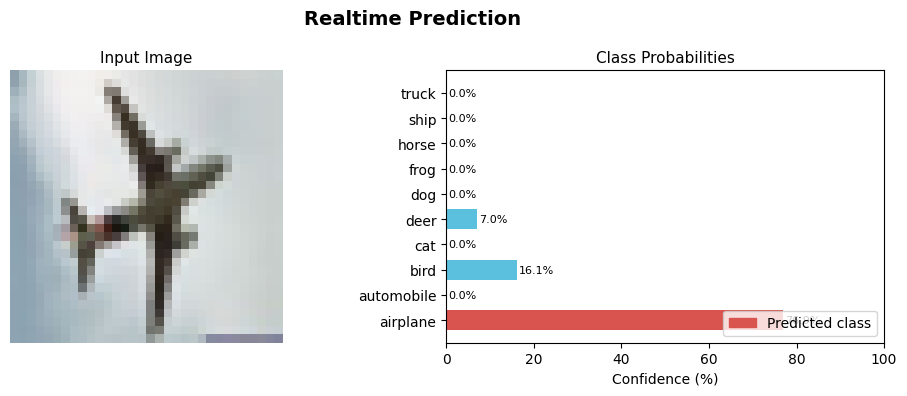

  Prediction : airplane
  Confidence : 76.9%


In [ ]:
# ============================================================
# SECTION 11: REALTIME IMAGE PREDICTION
# ============================================================
# This cell is designed for Google Colab.
# If running locally, replace the upload block with:
#   img_path = "/path/to/your/image.jpg"
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tensorflow.keras.utils import load_img, img_to_array

# --- Class labels ---
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# ----------------------------------------------------------------
# Step 1: Upload image  (Colab file upload widget)
# ----------------------------------------------------------------
try:
    from google.colab import files
    print("📂 Please upload an image file …")
    uploaded = files.upload()                         # opens file picker
    img_path = list(uploaded.keys())[0]               # path of first uploaded file
    print(f"Uploaded: {img_path}")

except ImportError:
    # ---- Fallback: use a random test image when NOT in Colab ----
    print("⚠️  google.colab not available — using a random test image instead.")
    idx = np.random.randint(0, len(x_test))
    # Save that test image temporarily so the rest of the code is identical
    img_array_uint8 = (x_test[idx] * 255).astype(np.uint8)
    from PIL import Image
    tmp_img = Image.fromarray(img_array_uint8)
    img_path = "sample_test_image.png"
    tmp_img.save(img_path)
    print(f"Using test image index {idx}  (true label: {class_names[y_true_classes[idx]]})")

# ----------------------------------------------------------------
# Step 2: Load & resize to 32×32
# ----------------------------------------------------------------
img_original = load_img(img_path)                     # PIL Image (original size)
img_resized  = load_img(img_path, target_size=(32, 32))

# ----------------------------------------------------------------
# Step 3: Normalize pixel values
# ----------------------------------------------------------------
img_array = img_to_array(img_resized) / 255.0         # shape: (32, 32, 3)
img_input = np.expand_dims(img_array, axis=0)         # shape: (1, 32, 32, 3)

# ----------------------------------------------------------------
# Step 4: Predict class using the loaded model
# ----------------------------------------------------------------
predictions   = loaded_model.predict(img_input, verbose=0)[0]  # shape: (10,)
pred_idx      = int(np.argmax(predictions))
pred_label    = class_names[pred_idx]
confidence    = float(predictions[pred_idx]) * 100

# ----------------------------------------------------------------
# Step 5: Display result
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Realtime Prediction", fontsize=14, fontweight='bold')

# --- Left: input image (original size) ---
axes[0].imshow(img_original)
axes[0].set_title("Input Image", fontsize=11)
axes[0].axis('off')

# --- Right: class probability bar chart ---
colors = ['#d9534f' if i == pred_idx else '#5bc0de' for i in range(10)]
axes[1].barh(class_names, predictions * 100, color=colors)
axes[1].set_xlabel("Confidence (%)")
axes[1].set_title("Class Probabilities", fontsize=11)
axes[1].set_xlim(0, 100)
for i, v in enumerate(predictions * 100):
    axes[1].text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=8)

highlight = mpatches.Patch(color='#d9534f', label='Predicted class')
axes[1].legend(handles=[highlight], loc='lower right')

plt.tight_layout()
plt.show()

print("=" * 40)
print(f"  Prediction : {pred_label}")
print(f"  Confidence : {confidence:.1f}%")
print("=" * 40)

## Section 12 — Plot Training Results

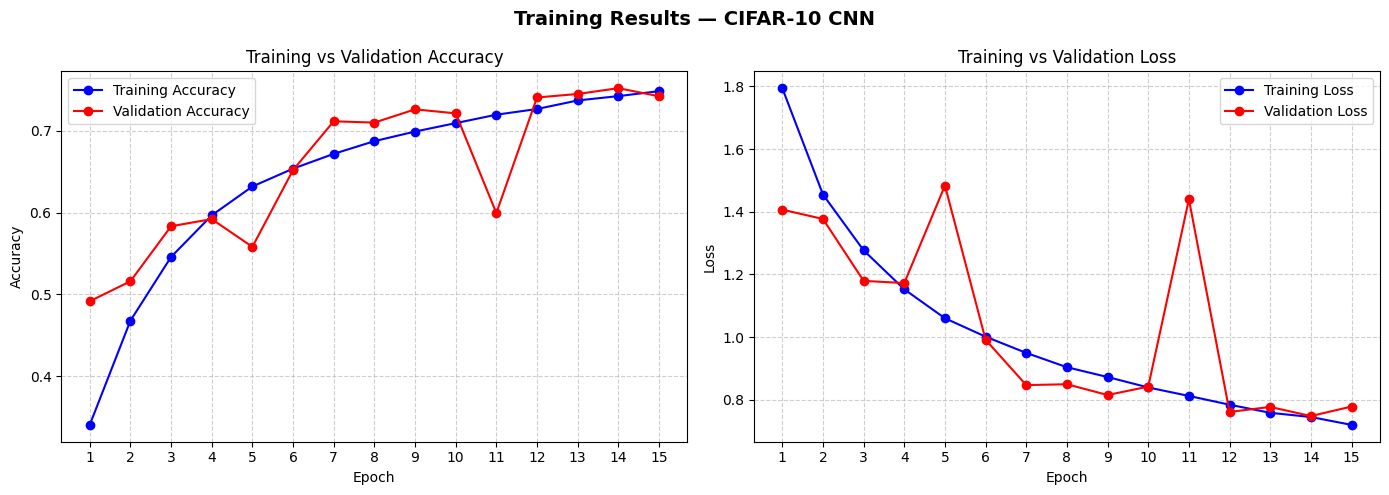

Training curves saved to 'training_results.png' ✅


In [ ]:
# ============================================================
# SECTION 12: PLOT TRAINING RESULTS
# ============================================================

epochs_range = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Results — CIFAR-10 CNN", fontsize=14, fontweight='bold')

# ---- Plot 1: Accuracy ----
axes[0].plot(epochs_range, history.history['accuracy'],     'b-o', label='Training Accuracy')
axes[0].plot(epochs_range, history.history['val_accuracy'], 'r-o', label='Validation Accuracy')
axes[0].set_title("Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xticks(epochs_range)

# ---- Plot 2: Loss ----
axes[1].plot(epochs_range, history.history['loss'],     'b-o', label='Training Loss')
axes[1].plot(epochs_range, history.history['val_loss'], 'r-o', label='Validation Loss')
axes[1].set_title("Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xticks(epochs_range)

plt.tight_layout()
plt.savefig("training_results.png", dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved to 'training_results.png' ✅")